In [1]:
%cd /content/drive/MyDrive/Colab\ Notebooks/transformer

/content/drive/MyDrive/Colab Notebooks/transformer


In [2]:
import sys, os
import torch
import math
import time
import matplotlib
import matplotlib.pyplot as plt

# **1. Configuration**

In [3]:
# Configuration Test & Inspection
from config import cfg, validate_config
validate_config(cfg)

print(f"\nConfig:")
print(f"  d_model={cfg.d_model}, n_heads={cfg.n_heads}, n_layers={cfg.n_layers}")
print(f"  d_ff={cfg.d_ff}, d_k={cfg.d_k}, d_v={cfg.d_v}")
print(f"  vocab_size={cfg.vocab_size}, max_seq_len={cfg.max_seq_len}")
print(f"  dropout={cfg.dropout}, label_smoothing={cfg.label_smoothing}")
print(f"  warmup_steps={cfg.warmup_steps}, batch_size={cfg.batch_size}")
print("="*100)
print(cfg)

[Config] Validated. d_model=512, n_heads=8, d_k=64, n_layers=6, d_ff=2048
[Config] Device: cpu

Config:
  d_model=512, n_heads=8, n_layers=6
  d_ff=2048, d_k=64, d_v=64
  vocab_size=37000, max_seq_len=128
  dropout=0.1, label_smoothing=0.1
  warmup_steps=4000, batch_size=32
TransformerConfig(d_model=512, n_heads=8, n_layers=6, d_ff=2048, dropout=0.1, max_seq_len=128, vocab_size=37000, batch_size=32, num_epochs=30, warmup_steps=4000, label_smoothing=0.1, PAD_IDX=0, SOS_IDX=1, EOS_IDX=2)


# **2. Embeddings**

EMBEDDING PIPELINE TESTS

[1] Token Embedding
  Input shape:  torch.Size([2, 50]) (token IDs)
  Output shape: torch.Size([2, 50, 512]) (dense vectors)
  Scale verification: PASSED
  PAD embedding norm: 0.0000 (expected 0.0000)
    Token embedding passed all mathematical checks.

[2] Positional Encoding
  PE matrix shape: torch.Size([128, 512])
  PE value range:  [-1.0000, 1.0000]
  PE(pos=0, dim=0) = 0.0000 (expected 0.0000 -> sin(0))
  PE(pos=0, dim=1) = 1.0000 (expected 1.0000 -> cos(0))
  Min diff between adjacent PE rows: 3.7143 (expected > 0)
    Positional encoding passed all mathematical checks.
    Positional encoding visualization rendered and saved to 'positional_encoding.png'


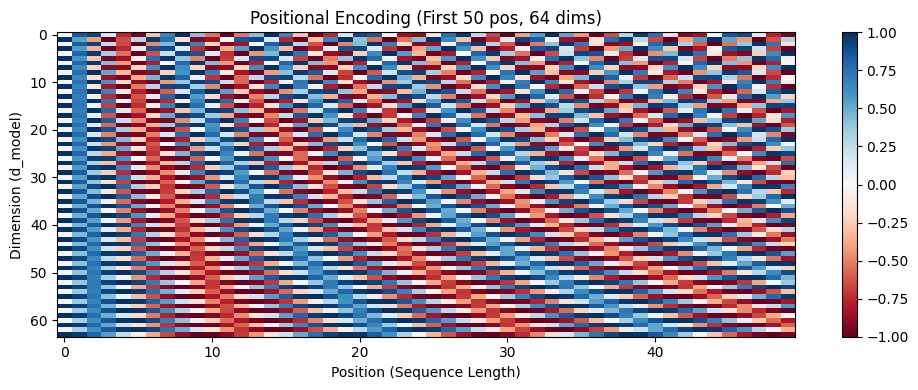


[3] Full Transformer Embedding
  Input shape:  torch.Size([2, 50])
  Output shape: torch.Size([2, 50, 512])
    Full embedding pipeline passed dimensional checks.

ALL EMBEDDING TESTS PASSED SUCCESSFULLY


In [4]:
# Embeddings Test & Inspection
%matplotlib inline
import torch
import math
import matplotlib.pyplot as plt
from config import cfg
from embeddings import TokenEmbedding, PositionalEncoding, TransformerEmbedding

print("=" * 60)
print("EMBEDDING PIPELINE TESTS")
print("=" * 60)

# Define mock batch parameters
B, S = 2, 50  # Using S=50 to make the PE plot visually meaningful

# ------------------------------------------------------------------------------
# [1] Token Embedding
# ------------------------------------------------------------------------------
print("\n[1] Token Embedding")
token_emb = TokenEmbedding(vocab_size=cfg.vocab_size, d_model=cfg.d_model)
x = torch.randint(1, cfg.vocab_size, (B, S))  # start at 1 to avoid PAD initially
out = token_emb(x)

print(f"  Input shape:  {x.shape} (token IDs)")
print(f"  Output shape: {out.shape} (dense vectors)")

# Assertions
assert out.shape == (B, S, cfg.d_model), f"Expected {(B, S, cfg.d_model)}, got {out.shape}"

# Verify scaling: output magnitude should be ~sqrt(d_model) times the raw embedding
raw = token_emb.embedding(x)
ratio = (out / raw).mean().item()
# Verify scaling: out should be exactly raw * sqrt(d_model)
expected_ratio = math.sqrt(cfg.d_model)
is_scaled_correctly = torch.allclose(out, raw * expected_ratio, atol=1e-5)

print(f"  Scale verification: {'PASSED' if is_scaled_correctly else 'FAILED'}")
assert is_scaled_correctly, f"Embedding scaling factor of sqrt({cfg.d_model}) was not applied correctly!"

# Verify PAD token receives a strict zero embedding
pad_tokens = torch.zeros(1, 3, dtype=torch.long)  # cfg.PAD_IDX == 0
pad_out = token_emb(pad_tokens)
print(f"  PAD embedding norm: {pad_out.norm().item():.4f} (expected 0.0000)")
assert pad_out.norm().item() < 1e-6, "PAD embedding should be strictly zero"

print("    Token embedding passed all mathematical checks.")

# ------------------------------------------------------------------------------
# [2] Positional Encoding
# ------------------------------------------------------------------------------
print("\n[2] Positional Encoding")
pe_module = PositionalEncoding(d_model=cfg.d_model, max_seq_len=cfg.max_seq_len, dropout=0.0)
pe_matrix = pe_module.pe[0]  # shape [max_seq_len, d_model]

print(f"  PE matrix shape: {pe_matrix.shape}")

# Value Range Checks (Sin/Cos bounds)
print(f"  PE value range:  [{pe_matrix.min():.4f}, {pe_matrix.max():.4f}]")
assert pe_matrix.min() >= -1.0 - 1e-6, "PE values fell below -1.0"
assert pe_matrix.max() <= 1.0 + 1e-6, "PE values exceeded 1.0"

# Position 0 Identity Checks
print(f"  PE(pos=0, dim=0) = {pe_matrix[0, 0].item():.4f} (expected 0.0000 -> sin(0))")
print(f"  PE(pos=0, dim=1) = {pe_matrix[0, 1].item():.4f} (expected 1.0000 -> cos(0))")
assert abs(pe_matrix[0, 0].item()) < 1e-6, "First even dimension should be sin(0)=0"
assert abs(pe_matrix[0, 1].item() - 1.0) < 1e-6, "First odd dimension should be cos(0)=1"

# Uniqueness Check (No two adjacent positions should have identical encodings)
diffs = (pe_matrix[:-1] - pe_matrix[1:]).norm(dim=-1)
print(f"  Min diff between adjacent PE rows: {diffs.min():.4f} (expected > 0)")
assert diffs.min().item() > 0.01, "Adjacent positions have identical encodings!"

print("    Positional encoding passed all mathematical checks.")

# --- Visualization ---
# Plot only the first 50 positions and 64 dimensions for a clean visual
vis_positions = min(50, cfg.max_seq_len)
vis_dims = min(64, cfg.d_model)
pe_matrix_vis = pe_matrix[:vis_positions, :vis_dims].detach().numpy()

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pe_matrix_vis.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Position (Sequence Length)')
ax.set_ylabel('Dimension (d_model)')
ax.set_title(f'Positional Encoding (First {vis_positions} pos, {vis_dims} dims)')
plt.colorbar(im, ax=ax)
plt.tight_layout()

# Save, Show, then Close
plt.savefig('positional_encoding.png', dpi=100, bbox_inches='tight')
print("    Positional encoding visualization rendered and saved to 'positional_encoding.png'")
plt.show()
plt.close()

# ------------------------------------------------------------------------------
# [3] Full Transformer Embedding
# ------------------------------------------------------------------------------
print("\n[3] Full Transformer Embedding")
full_emb = TransformerEmbedding(vocab_size=cfg.vocab_size, d_model=cfg.d_model,
                                max_seq_len=cfg.max_seq_len, dropout=0.0)

# Avoid PAD tokens to ensure the dropout/addition logic works on real values
x_full = torch.randint(1, cfg.vocab_size, (B, S))
out_full = full_emb(x_full)

print(f"  Input shape:  {x_full.shape}")
print(f"  Output shape: {out_full.shape}")
assert out_full.shape == (B, S, cfg.d_model), f"Expected {(B, S, cfg.d_model)}, got {out_full.shape}"
print("    Full embedding pipeline passed dimensional checks.")

print("\n" + "=" * 60)
print("ALL EMBEDDING TESTS PASSED SUCCESSFULLY")
print("=" * 60)

# **3. Masks**

In [5]:
# Masks Test & Inspection
import torch
from masks import make_src_mask, make_causal_mask, make_tgt_mask

print("=" * 60)
print("MASK PIPELINE TESTS")
print("=" * 60)

# ------------------------------------------------------------------------------
# [1] Padding Mask (Source Mask)
# ------------------------------------------------------------------------------
print("\n[1] Padding Mask (Source Mask)")
# Sequence 0 has 2 PAD tokens. Sequence 1 has 0 PAD tokens.
src = torch.tensor([[1, 2, 3, 0, 0],
                    [4, 5, 6, 7, 8]])
pm = make_src_mask(src, pad_idx=0)

print(f"  Input shape:  {src.shape}")
print(f"  Mask shape:   {pm.shape}")  # [2, 1, 1, 5]

# Assertions
assert pm.shape == (2, 1, 1, 5), f"Expected shape (2, 1, 1, 5), got {pm.shape}"
assert pm[0, 0, 0, 3].item() == True, "Failed: PAD position not masked!"
assert pm[1, 0, 0, 4].item() == False, "Failed: Real token was incorrectly masked!"

# Visual Verification
print(f"  Row 0 (has padding): {[ 'BLOCKED' if x else 'Allowed' for x in pm[0,0,0].tolist() ]}")
print(f"  Row 1 (no padding):  {[ 'BLOCKED' if x else 'Allowed' for x in pm[1,0,0].tolist() ]}")
print("    Padding mask passed all checks.")

# ------------------------------------------------------------------------------
# [2] Causal Mask (Look-Ahead Mask)
# ------------------------------------------------------------------------------
print("\n[2] Causal Mask (Look-Ahead Mask)")
seq_len = 5
cm = make_causal_mask(seq_len)

print(f"  Mask shape:   {cm.shape}")  # [1, 1, 5, 5]

# Assertions
assert cm.shape == (1, 1, seq_len, seq_len), f"Expected shape (1, 1, 5, 5), got {cm.shape}"
assert cm[0, 0, 0, 1].item() == True, "Failed: Position 0 should not see Position 1"
assert cm[0, 0, 1, 0].item() == False, "Failed: Position 1 should be able to see Position 0"
assert cm[0, 0, 4, 4].item() == False, "Failed: Position 4 should be able to see itself"

# Visual Verification
print("  Attention Grid (Row=Query, Col=Key):")
for i in range(seq_len):
    row = ['[#]' if cm[0, 0, i, j] else '[ ]' for j in range(seq_len)]
    print(f"    Pos {i}: {' '.join(row)}  (# = blocked future)")
print("    Causal mask passed all checks.")

# ------------------------------------------------------------------------------
# [3] Combined Target Mask (Decoder Mask)
# ------------------------------------------------------------------------------
print("\n[3] Combined Target Mask (Decoder Mask)")
tgt = torch.tensor([[1, 2, 3, 0, 0],
                    [4, 5, 6, 7, 8]])
tm = make_tgt_mask(tgt, pad_idx=0)

print(f"  Input shape:  {tgt.shape}")
print(f"  Mask shape:   {tm.shape}")  # [2, 1, 5, 5]

# Assertions
assert tm.shape == (2, 1, 5, 5), f"Expected shape (2, 1, 5, 5), got {tm.shape}"
assert tm[0, 0, 0, 1].item() == True, "Failed: Future position not masked by causal logic"
assert tm[0, 0, 3, 3].item() == True, "Failed: Current position is PAD, should be masked by padding logic"
assert tm[0, 0, 2, 4].item() == True, "Failed: Future PAD position should be masked"

# Visual Verification for Row 0 (Which contains padding)
print("  Attention Grid for Sequence 0 (Contains PAD at pos 3, 4):")
for i in range(seq_len):
    row = ['[#]' if tm[0, 0, i, j] else '[ ]' for j in range(seq_len)]
    print(f"    Pos {i}: {' '.join(row)}  (# = blocked future OR blocked PAD)")
print("    Combined mask passed all checks.")

print("\n" + "=" * 60)
print("ALL MASK TESTS PASSED SUCCESSFULLY")
print("=" * 60)

MASK PIPELINE TESTS

[1] Padding Mask (Source Mask)
  Input shape:  torch.Size([2, 5])
  Mask shape:   torch.Size([2, 1, 1, 5])
  Row 0 (has padding): ['Allowed', 'Allowed', 'Allowed', 'BLOCKED', 'BLOCKED']
  Row 1 (no padding):  ['Allowed', 'Allowed', 'Allowed', 'Allowed', 'Allowed']
    Padding mask passed all checks.

[2] Causal Mask (Look-Ahead Mask)
  Mask shape:   torch.Size([1, 1, 5, 5])
  Attention Grid (Row=Query, Col=Key):
    Pos 0: [ ] [#] [#] [#] [#]  (# = blocked future)
    Pos 1: [ ] [ ] [#] [#] [#]  (# = blocked future)
    Pos 2: [ ] [ ] [ ] [#] [#]  (# = blocked future)
    Pos 3: [ ] [ ] [ ] [ ] [#]  (# = blocked future)
    Pos 4: [ ] [ ] [ ] [ ] [ ]  (# = blocked future)
    Causal mask passed all checks.

[3] Combined Target Mask (Decoder Mask)
  Input shape:  torch.Size([2, 5])
  Mask shape:   torch.Size([2, 1, 5, 5])
  Attention Grid for Sequence 0 (Contains PAD at pos 3, 4):
    Pos 0: [ ] [#] [#] [#] [#]  (# = blocked future OR blocked PAD)
    Pos 1: [ ] [ ]

# **4. Attention**

In [6]:
# Attention Test & Inspection
import torch
from masks import make_src_mask, make_tgt_mask, make_causal_mask
from attention import scaled_dot_product_attention, MultiHeadAttention

print("=" * 60)
print("ATTENTION PIPELINE TESTS")
print("=" * 60)

# Define mock dimensions
B, S, d_model, n_heads = 2, 5, 512, 8
d_k = d_model // n_heads  # 64

# ------------------------------------------------------------------------------
# [1] Scaled Dot-Product Attention (Raw computation)
# ------------------------------------------------------------------------------
print("\n[1] Scaled Dot-Product Attention (Unmasked)")
Q = torch.randn(B, n_heads, S, d_k)
K = torch.randn(B, n_heads, S, d_k)
V = torch.randn(B, n_heads, S, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print(f"  Q, K, V shapes: {Q.shape}")
print(f"  Output shape:   {output.shape}")  # [2, 8, 5, 64]
print(f"  Weights shape:  {weights.shape}") # [2, 8, 5, 5]

# Assertions
assert output.shape == (B, n_heads, S, d_k), f"Expected {(B, n_heads, S, d_k)}, got {output.shape}"
assert weights.shape == (B, n_heads, S, S), f"Expected {(B, n_heads, S, S)}, got {weights.shape}"

# Verify Softmax Application (Rows must sum to ~1.0)
weight_sums = weights.sum(dim=-1)
print(f"  Weight row sums (Pos 0): {weight_sums[0, 0].tolist()}")
assert torch.allclose(weight_sums, torch.ones_like(weight_sums), atol=1e-5), "Attention weights do not sum to 1.0!"
print("    Scaled dot-product attention passed.")

from masks import make_src_mask, make_tgt_mask, make_causal_mask

# ------------------------------------------------------------------------------
# [2] Scaled Dot-Product Attention (With All Mask Types)
# ------------------------------------------------------------------------------
# Setup mock token IDs (B=2, S=5) to generate realistic masks
mock_tokens = torch.tensor([[1, 2, 3, 0, 0],   # Batch 0: 2 PAD tokens at the end
                            [4, 5, 6, 7, 8]])  # Batch 1: No PAD tokens

# --- 2A: Causal Mask ---
print("\n[2A] Scaled Dot-Product Attention (Causal Masking)")
causal_mask = make_causal_mask(S)  # [1, 1, 5, 5]
_, weights_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

future_weights = weights_causal[0, 0, 0, 1:]  # Position 0 looking at positions 1,2,3,4
print(f"  Future weights for Pos 0: {future_weights.tolist()} (Expected all 0.0)")
assert torch.allclose(future_weights, torch.zeros_like(future_weights), atol=1e-6), "Masking failed: Future weights are not zero!"
print("    Causal masking logic passed.")

# --- 2B: Padding Mask ---
print("\n[2B] Scaled Dot-Product Attention (Padding Masking)")
pad_mask = make_src_mask(mock_tokens, pad_idx=0) # [2, 1, 1, 5]
_, weights_pad = scaled_dot_product_attention(Q, K, V, mask=pad_mask)

# In Batch 0, positions 3 and 4 are PAD. NO query should be able to attend to them.
pad_weights = weights_pad[0, 0, :, 3:] # Batch 0, Head 0, All Queries, Keys 3 & 4
print(f"  PAD weights (Batch 0, Keys 3-4): {pad_weights[0].tolist()} (Expected all 0.0)")
assert torch.allclose(pad_weights, torch.zeros_like(pad_weights), atol=1e-6), "Masking failed: Attended to PAD tokens!"

# In Batch 1, there are no PAD tokens, so weights should NOT be zeroed out artificially.
valid_weights = weights_pad[1, 0, :, 3:]
assert not torch.allclose(valid_weights, torch.zeros_like(valid_weights)), "Masking failed: Blanked out valid tokens in Batch 1!"
print("    Padding masking logic passed.")

# --- 2C: Combined Mask ---
print("\n[2C] Scaled Dot-Product Attention (Combined Masking)")
combined_mask = make_tgt_mask(mock_tokens, pad_idx=0) # [2, 1, 5, 5]
_, weights_combined = scaled_dot_product_attention(Q, K, V, mask=combined_mask)

# Check 1: Did it apply the Causal rule? (Pos 0 cannot see Pos 1)
future_combined = weights_combined[0, 0, 0, 1:]
assert torch.allclose(future_combined, torch.zeros_like(future_combined), atol=1e-6), "Combined mask failed causal check!"

# Check 2: Did it apply the Padding rule? (Pos 2 cannot see Pos 3, even though it's 'future', it's also PAD)
pad_combined = weights_combined[0, 0, :, 3:]
assert torch.allclose(pad_combined, torch.zeros_like(pad_combined), atol=1e-6), "Combined mask failed padding check!"
print("    Combined masking logic passed.")

# ------------------------------------------------------------------------------
# [3] Multi-Head Attention (Self-Attention & Architecture)
# ------------------------------------------------------------------------------
print("\n[3] Multi-Head Self-Attention")
mha = MultiHeadAttention(d_model=d_model, n_heads=n_heads, dropout=0.0)

x = torch.randn(B, S, d_model)
output_mha = mha(x, x, x)

print(f"  Input shape:  {x.shape}")
print(f"  Output shape: {output_mha.shape}")
assert output_mha.shape == x.shape, "MHA output shape does not match input shape!"
print("    Self-Attention dimensional flow passed.")

# ------------------------------------------------------------------------------
# [4] Multi-Head Cross-Attention (Differing Sequence Lengths)
# ------------------------------------------------------------------------------
print("\n[4] Multi-Head Cross-Attention (S_q != S_k)")
S_q, S_k = 4, 6  # e.g., Decoder length 4 attending to Encoder length 6
Q_cross = torch.randn(B, S_q, d_model)   # Decoder queries
KV_cross = torch.randn(B, S_k, d_model)  # Encoder keys/values

output_cross = mha(Q_cross, KV_cross, KV_cross)

print(f"  Q shape (Decoder): {Q_cross.shape}")
print(f"  K/V shape (Encoder): {KV_cross.shape}")
print(f"  Output shape: {output_cross.shape}")
assert output_cross.shape == (B, S_q, d_model), "Cross-attention failed to match Query sequence length!"
print("    Cross-Attention dimensional flow passed.")

# ------------------------------------------------------------------------------
# [5] Tensor Manipulation Consistency (Split/Combine Heads)
# ------------------------------------------------------------------------------
print("\n[5] Split/Combine Head Consistency")
x_test = torch.randn(B, S, d_model)
projected = mha.W_Q(x_test)              # [B, S, d_model]
split = mha.split_heads(projected)       # [B, n_heads, S, d_k]
recombined = mha.combine_heads(split)    # [B, S, d_model]

assert torch.allclose(projected, recombined), "split_heads -> combine_heads alters the original tensor data!"
print("    split_heads and combine_heads form a perfect identity loop.")

# ------------------------------------------------------------------------------
# [6] Parameter Verification
# ------------------------------------------------------------------------------
print("\n[6] MHA Parameter Verification")
n_params = sum(p.numel() for p in mha.parameters())

# 4 Projections (Q, K, V, O) * (Weight matrix [d_model, d_model] + Bias vector [d_model])
expected_mha_params = 4 * (d_model ** 2) + 4 * d_model

print(f"  MHA Trainable Parameters: {n_params:,}")
print(f"  Mathematical Expectation: {expected_mha_params:,}")
assert n_params == expected_mha_params, "MHA parameter count mismatch!"
print("    Parameter counts match exact theoretical expectations.")

print("\n" + "=" * 60)
print("ALL ATTENTION TESTS PASSED SUCCESSFULLY")
print("=" * 60)

ATTENTION PIPELINE TESTS

[1] Scaled Dot-Product Attention (Unmasked)
  Q, K, V shapes: torch.Size([2, 8, 5, 64])
  Output shape:   torch.Size([2, 8, 5, 64])
  Weights shape:  torch.Size([2, 8, 5, 5])
  Weight row sums (Pos 0): [1.0, 1.0, 0.9999999403953552, 1.0000001192092896, 0.9999999403953552]
    Scaled dot-product attention passed.

[2A] Scaled Dot-Product Attention (Causal Masking)
  Future weights for Pos 0: [0.0, 0.0, 0.0, 0.0] (Expected all 0.0)
    Causal masking logic passed.

[2B] Scaled Dot-Product Attention (Padding Masking)
  PAD weights (Batch 0, Keys 3-4): [0.0, 0.0] (Expected all 0.0)
    Padding masking logic passed.

[2C] Scaled Dot-Product Attention (Combined Masking)
    Combined masking logic passed.

[3] Multi-Head Self-Attention
  Input shape:  torch.Size([2, 5, 512])
  Output shape: torch.Size([2, 5, 512])
    Self-Attention dimensional flow passed.

[4] Multi-Head Cross-Attention (S_q != S_k)
  Q shape (Decoder): torch.Size([2, 4, 512])
  K/V shape (Encoder)

# **5. FFN**


In [7]:
# Feed-Forward Network Test & Inspection
import torch
from config import cfg
from feedforward import PositionwiseFeedForward

print("=" * 60)
print("FEED-FORWARD NETWORK (FFN) PIPELINE TESTS")
print("=" * 60)

# Define mock dimensions
B, S = 2, 5
d_model = cfg.d_model
d_ff = cfg.d_ff

# Instantiate FFN
ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=0.0)
x = torch.randn(B, S, d_model)

# ------------------------------------------------------------------------------
# [1] Dimensional Flow & Shape Test
# ------------------------------------------------------------------------------
print("\n[1] Dimensional Flow Test")
output = ffn(x)

print(f"  Input shape:  {x.shape}")
print(f"  Output shape: {output.shape}")
assert output.shape == x.shape, f"FFN output must match input shape. Got {output.shape}"
print("    End-to-end dimensional flow passed.")

# ------------------------------------------------------------------------------
# [2] Position Independence Test ("Position-wise" validation)
# ------------------------------------------------------------------------------
print("\n[2] Position Independence Test")
# Apply FFN to just position 2 isolated from the rest of the sequence
out_pos2_isolated = ffn(x[:, 2:3, :])  # [B, 1, d_model]

# Extract position 2 from the full sequence output
out_pos2_extracted = output[:, 2:3, :] # [B, 1, d_model]

# Compare the isolated processing vs bulk processing
diff = (out_pos2_extracted - out_pos2_isolated).abs().max()
print(f"  Max diff between bulk sequence and isolated position: {diff.item():.6e}")

assert diff.item() < 1e-5, "FAILED: FFN showed cross-talk between positions!"
print("    Position independence confirmed (No cross-sequence data leakage).")

# ------------------------------------------------------------------------------
# [3] Intermediate Sub-layer Shape Tracing
# ------------------------------------------------------------------------------
print("\n[3] Internal Sub-layer Flow Check")
x_test = torch.randn(1, 1, d_model)  # Single token test

# Manually step through the module
after_l1 = ffn.linear1(x_test)
after_relu = ffn.relu(after_l1)
after_l2 = ffn.linear2(after_relu)

print(f"  Input:      {x_test.shape}     -> (d_model)")
print(f"  After L1:   {after_l1.shape}    -> (Expanded to d_ff)")
print(f"  After ReLU: {after_relu.shape}    -> (Non-linear activation)")
print(f"  After L2:   {after_l2.shape}     -> (Compressed back to d_model)")

assert after_l1.shape == (1, 1, d_ff), "Linear 1 failed to expand to d_ff."
assert after_l2.shape == (1, 1, d_model), "Linear 2 failed to compress back to d_model."

# Diagnostic: Check dead/active neurons
frac_active = (after_relu > 0).float().mean().item()
print(f"  Diagnostic: Fraction of neurons active after ReLU: {frac_active:.2%}")
print("    Internal architectural routing passed.")

# ------------------------------------------------------------------------------
# [4] Parameter Verification
# ------------------------------------------------------------------------------
print("\n[4] FFN Parameter Verification")
n_params = sum(p.numel() for p in ffn.parameters())

# Expected math: (W1 + b1) + (W2 + b2)
expected_ffn_params = (d_model * d_ff + d_ff) + (d_ff * d_model + d_model)

print(f"  FFN Trainable Parameters: {n_params:,}")
print(f"  Mathematical Expectation: {expected_ffn_params:,}")
assert n_params == expected_ffn_params, "FFN parameter count mismatch!"
print("    Parameter counts match exact theoretical expectations.")

print("\n" + "=" * 60)
print("ALL FFN TESTS PASSED SUCCESSFULLY")
print("=" * 60)

FEED-FORWARD NETWORK (FFN) PIPELINE TESTS

[1] Dimensional Flow Test
  Input shape:  torch.Size([2, 5, 512])
  Output shape: torch.Size([2, 5, 512])
    End-to-end dimensional flow passed.

[2] Position Independence Test
  Max diff between bulk sequence and isolated position: 4.023314e-07
    Position independence confirmed (No cross-sequence data leakage).

[3] Internal Sub-layer Flow Check
  Input:      torch.Size([1, 1, 512])     -> (d_model)
  After L1:   torch.Size([1, 1, 2048])    -> (Expanded to d_ff)
  After ReLU: torch.Size([1, 1, 2048])    -> (Non-linear activation)
  After L2:   torch.Size([1, 1, 512])     -> (Compressed back to d_model)
  Diagnostic: Fraction of neurons active after ReLU: 50.24%
    Internal architectural routing passed.

[4] FFN Parameter Verification
  FFN Trainable Parameters: 2,099,712
  Mathematical Expectation: 2,099,712
    Parameter counts match exact theoretical expectations.

ALL FFN TESTS PASSED SUCCESSFULLY


# **6. Test Encoder**

In [8]:
# Encoder Test & Inspection
import torch
from config import cfg
from masks import make_src_mask
from encoder import EncoderLayer, Encoder

print("=" * 60)
print("ENCODER PIPELINE TESTS")
print("=" * 60)

# Define mock dimensions
B, S = 2, 5
d_model = cfg.d_model
n_heads = cfg.n_heads
d_ff = cfg.d_ff
n_layers = cfg.n_layers

x = torch.randn(B, S, d_model)

# ------------------------------------------------------------------------------
# [1] Single Encoder Layer - Dimensional Flow
# ------------------------------------------------------------------------------
print("\n[1] Single Encoder Layer (Shape Flow)")
enc_layer = EncoderLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=0.0)
out_layer = enc_layer(x)

print(f"  Input shape:  {x.shape}")
print(f"  Output shape: {out_layer.shape}")
assert out_layer.shape == x.shape, f"Layer output shape must match input. Got {out_layer.shape}"
print("    Single layer dimensional flow passed.")

# ------------------------------------------------------------------------------
# [2] Encoder Layer with Padding Mask Integration
# ------------------------------------------------------------------------------
print("\n[2] Encoder Layer (Padding Mask Integration)")
# Mock tokens: Batch 0 has 2 PAD tokens, Batch 1 has none
src_tokens = torch.tensor([[1, 2, 3, 0, 0],
                           [4, 5, 6, 7, 8]])
pad_mask = make_src_mask(src_tokens, pad_idx=0)

print(f"  Generated Mask shape: {pad_mask.shape}")
out_masked = enc_layer(x, mask=pad_mask)

print(f"  Masked Output shape:  {out_masked.shape}")
assert out_masked.shape == x.shape, "Applying mask disrupted output dimensional flow!"
print("    Encoder layer successfully processed the padding mask without errors.")

# ------------------------------------------------------------------------------
# [3] Full Encoder Stack Integration
# ------------------------------------------------------------------------------
print(f"\n[3] Full Encoder Stack ({n_layers} layers)")
encoder = Encoder(n_layers=n_layers, d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=0.0)
out_enc = encoder(x, mask=pad_mask)

print(f"  Input shape:  {x.shape}")
print(f"  Output shape: {out_enc.shape}")
assert out_enc.shape == (B, S, d_model), f"Expected {(B, S, d_model)}, got {out_enc.shape}"
print("    Full encoder stack dimensional flow passed.")

# ------------------------------------------------------------------------------
# [4] Parameter Verification
# ------------------------------------------------------------------------------
print("\n[4] Encoder Parameter Verification")

# 1. Attention params (W_Q, W_K, W_V, W_O + biases)
attn_params = 4 * ((d_model ** 2) + d_model)

# 2. FFN params (W1, b1, W2, b2)
ffn_params = 2 * (d_model * d_ff) + d_ff + d_model

# 3. LayerNorm params (2 instances per layer, each has gamma & beta)
ln_params = 2 * (2 * d_model)

# Compute expected total for a single layer, then scale by N layers
expected_single_layer = attn_params + ffn_params + ln_params
expected_total_params = n_layers * expected_single_layer

# Pull physical counts from PyTorch state tree
actual_layer_params = sum(p.numel() for p in enc_layer.parameters())
actual_total_params = sum(p.numel() for p in encoder.parameters())

print(f"  Single Layer Trainable Count:   {actual_layer_params:,}")
print(f"  Single Layer Math Expectation:  {expected_single_layer:,}")
assert actual_layer_params == expected_single_layer, "Single layer parameter mismatch!"

print(f"  " + "-"*40)
print(f"  Full Stack Trainable Count:     {actual_total_params:,}")
print(f"  Full Stack Math Expectation:    {expected_total_params:,}")
assert actual_total_params == expected_total_params, "Full encoder stack parameter mismatch!"
print("    Parameter counts match exact theoretical expectations.")

print("\n" + "=" * 60)
print("ALL ENCODER TESTS PASSED SUCCESSFULLY")
print("=" * 60)

ENCODER PIPELINE TESTS

[1] Single Encoder Layer (Shape Flow)
  Input shape:  torch.Size([2, 5, 512])
  Output shape: torch.Size([2, 5, 512])
    Single layer dimensional flow passed.

[2] Encoder Layer (Padding Mask Integration)
  Generated Mask shape: torch.Size([2, 1, 1, 5])
  Masked Output shape:  torch.Size([2, 5, 512])
    Encoder layer successfully processed the padding mask without errors.

[3] Full Encoder Stack (6 layers)
  Input shape:  torch.Size([2, 5, 512])
  Output shape: torch.Size([2, 5, 512])
    Full encoder stack dimensional flow passed.

[4] Encoder Parameter Verification
  Single Layer Trainable Count:   3,152,384
  Single Layer Math Expectation:  3,152,384
  ----------------------------------------
  Full Stack Trainable Count:     18,914,304
  Full Stack Math Expectation:    18,914,304
    Parameter counts match exact theoretical expectations.

ALL ENCODER TESTS PASSED SUCCESSFULLY


# **7. Test Decoder**

In [9]:
# Decoder Test & Inspection
import torch
from config import cfg
from masks import make_tgt_mask, make_src_mask
from decoder import DecoderLayer, Decoder

print("=" * 60)
print("DECODER PIPELINE TESTS")
print("=" * 60)

# Define mock dimensions
B = 2
S_tgt = 4  # Target sequence length (Decoder)
S_src = 5  # Source sequence length (Encoder)
d_model = cfg.d_model
n_heads = cfg.n_heads
d_ff = cfg.d_ff
n_layers = cfg.n_layers

tgt = torch.randn(B, S_tgt, d_model)
memory = torch.randn(B, S_src, d_model)

# ------------------------------------------------------------------------------
# [1] Single Decoder Layer - Dimensional Flow
# ------------------------------------------------------------------------------
print("\n[1] Single Decoder Layer (Shape Flow)")
dec_layer = DecoderLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=0.0)
out_layer = dec_layer(tgt, memory)

print(f"  Target input shape: {tgt.shape}")
print(f"  Memory input shape: {memory.shape} (From Encoder)")
print(f"  Output shape:       {out_layer.shape}")
assert out_layer.shape == tgt.shape, f"Layer output shape must match target input. Got {out_layer.shape}"
print("    Single layer dimensional flow passed.")

# ------------------------------------------------------------------------------
# [2] Decoder Layer with Mask Integration
# ------------------------------------------------------------------------------
print("\n[2] Decoder Layer (Mask Integration)")
# Mock tokens to generate realistic masks
tgt_tokens = torch.tensor([[1, 2, 3, 0],    # Batch 0: 1 PAD token
                           [4, 5, 6, 7]])   # Batch 1: No PAD
src_tokens = torch.tensor([[1, 2, 3, 0, 0], # Batch 0: 2 PAD tokens
                           [4, 5, 6, 7, 8]])# Batch 1: No PAD

t_mask = make_tgt_mask(tgt_tokens, pad_idx=0) # [B, 1, S_tgt, S_tgt] -> Causal + Pad
m_mask = make_src_mask(src_tokens, pad_idx=0) # [B, 1, 1, S_src] -> Source Pad

print(f"  Generated Target Mask shape: {t_mask.shape}")
print(f"  Generated Memory Mask shape: {m_mask.shape}")

out_masked = dec_layer(tgt, memory, tgt_mask=t_mask, memory_mask=m_mask)
print(f"  Masked Output shape:         {out_masked.shape}")
assert out_masked.shape == tgt.shape, "Applying masks disrupted output dimensional flow!"
print("    Decoder layer successfully processed causal and padding masks.")

# ------------------------------------------------------------------------------
# [3] Cross-Attention Dependency Check
# ------------------------------------------------------------------------------
print("\n[3] Cross-Attention Dependency Verification")
# The decoder output MUST depend on the memory (encoder output).
# If we change the memory, the output should change.
memory_alt = torch.randn(B, S_src, d_model)
out_alt = dec_layer(tgt, memory_alt)

diff = (out_layer - out_alt).abs().mean()
print(f"  Output diff when memory changes: {diff.item():.6e} (Expected > 0)")
assert diff.item() > 1e-4, "FAILED: Decoder output ignored the Encoder memory!"
print("    Cross-attention dependency confirmed (Decoder is successfully reading Encoder memory).")

# ------------------------------------------------------------------------------
# [4] Full Decoder Stack Integration
# ------------------------------------------------------------------------------
print(f"\n[4] Full Decoder Stack ({n_layers} layers)")
decoder = Decoder(n_layers=n_layers, d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=0.0)
out_dec = decoder(tgt, memory, tgt_mask=t_mask, memory_mask=m_mask)

print(f"  Input tgt shape: {tgt.shape}")
print(f"  Output shape:    {out_dec.shape}")
assert out_dec.shape == (B, S_tgt, d_model), f"Expected {(B, S_tgt, d_model)}, got {out_dec.shape}"
print("    Full decoder stack dimensional flow passed.")

# ------------------------------------------------------------------------------
# [5] Parameter Verification
# ------------------------------------------------------------------------------
print("\n[5] Decoder Parameter Verification")

# 1. Masked Self-Attention (W_Q, W_K, W_V, W_O + biases)
self_attn_params = 4 * ((d_model ** 2) + d_model)

# 2. Cross-Attention (W_Q, W_K, W_V, W_O + biases)
cross_attn_params = 4 * ((d_model ** 2) + d_model)

# 3. FFN params (W1, b1, W2, b2)
ffn_params = 2 * (d_model * d_ff) + d_ff + d_model

# 4. LayerNorm params (3 instances per layer, each has gamma & beta)
ln_params = 3 * (2 * d_model)

# Compute expected total for a single layer, then scale by N layers
expected_single_layer = self_attn_params + cross_attn_params + ffn_params + ln_params
expected_total_params = n_layers * expected_single_layer

# Pull physical counts from PyTorch state tree
actual_layer_params = sum(p.numel() for p in dec_layer.parameters())
actual_total_params = sum(p.numel() for p in decoder.parameters())

print(f"  Single Layer Trainable Count:   {actual_layer_params:,}")
print(f"  Single Layer Math Expectation:  {expected_single_layer:,}")
assert actual_layer_params == expected_single_layer, "Single layer parameter mismatch!"

print(f"  " + "-"*40)
print(f"  Full Stack Trainable Count:     {actual_total_params:,}")
print(f"  Full Stack Math Expectation:    {expected_total_params:,}")
assert actual_total_params == expected_total_params, "Full decoder stack parameter mismatch!"
print("    Parameter counts match exact theoretical expectations.")

print("\n" + "=" * 60)
print("ALL DECODER TESTS PASSED SUCCESSFULLY")
print("=" * 60)

DECODER PIPELINE TESTS

[1] Single Decoder Layer (Shape Flow)
  Target input shape: torch.Size([2, 4, 512])
  Memory input shape: torch.Size([2, 5, 512]) (From Encoder)
  Output shape:       torch.Size([2, 4, 512])
    Single layer dimensional flow passed.

[2] Decoder Layer (Mask Integration)
  Generated Target Mask shape: torch.Size([2, 1, 4, 4])
  Generated Memory Mask shape: torch.Size([2, 1, 1, 5])
  Masked Output shape:         torch.Size([2, 4, 512])
    Decoder layer successfully processed causal and padding masks.

[3] Cross-Attention Dependency Verification
  Output diff when memory changes: 1.853928e-01 (Expected > 0)
    Cross-attention dependency confirmed (Decoder is successfully reading Encoder memory).

[4] Full Decoder Stack (6 layers)
  Input tgt shape: torch.Size([2, 4, 512])
  Output shape:    torch.Size([2, 4, 512])
    Full decoder stack dimensional flow passed.

[5] Decoder Parameter Verification
  Single Layer Trainable Count:   4,204,032
  Single Layer Math Exp

# **8. Full Transformer Model**

In [10]:
# Full Transformer Test & Inspection
import torch
import torch.nn.functional as F
from config import cfg
from masks import make_src_mask
from transformer import build_transformer

print("=" * 60)
print("FULL TRANSFORMER PIPELINE TESTS")
print("=" * 60)

# 1. Setup & Instantiation
B, S_src, S_tgt = 2, 5, 4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = build_transformer(cfg).to(device)
model.eval()

FULL TRANSFORMER PIPELINE TESTS
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048


Transformer(
  (shared_embedding): TokenEmbedding(
    (embedding): Embedding(37000, 512, padding_idx=0)
  )
  (src_embedding): TransformerEmbedding(
    (token_embedding): TokenEmbedding(
      (embedding): Embedding(37000, 512, padding_idx=0)
    )
    (positional_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (tgt_embedding): TransformerEmbedding(
    (token_embedding): TokenEmbedding(
      (embedding): Embedding(37000, 512, padding_idx=0)
    )
    (positional_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=512, out_features=512, bias=True)
          (W_K): Linear(in_features=512, out_features=512, bias=True)
          (W_V): Linear(in_features=512, out_features=512, bias=True)
          (W_O): Linear(in_features=512, out_features=512, bias=

In [11]:
# Prepare mock tensors with explicit padding visualization
src = torch.randint(1, cfg.vocab_size, (B, S_src)).to(device)
tgt = torch.randint(1, cfg.vocab_size, (B, S_tgt)).to(device)
src[0, 3:] = cfg.PAD_IDX  # Force trailing positions in Batch 0 to be PAD tokens

# ------------------------------------------------------------------------------
# [1] Weight-Tying Verification
# ------------------------------------------------------------------------------
print("\n[1] Weight-Tying Verification")
emb_weight = model.shared_embedding.embedding.weight
proj_weight = model.output_projection.weight

# Verify shared weights are literally pointing to the exact same memory address
assert emb_weight.data_ptr() == proj_weight.data_ptr(), "Weight tying failed! Tensors do not share memory."
print("    Source Embedding, Target Embedding, and Output Projection perfectly share memory.")

# ------------------------------------------------------------------------------
# [2] Full Forward Pass & Dimensional Flow (Teacher Forcing)
# ------------------------------------------------------------------------------
print("\n[2] Full Forward Pass (Teacher Forcing Mode)")
with torch.no_grad():
    logits = model(src, tgt)

print(f"  Input Source shape: {src.shape}  -> Example Row 0: {src[0].tolist()}")
print(f"  Input Target shape: {tgt.shape}  -> Example Row 0: {tgt[0].tolist()}")
print(f"  Output Logits shape: {logits.shape}")

assert logits.shape == (B, S_tgt, cfg.vocab_size), f"Expected {(B, S_tgt, cfg.vocab_size)}, got {logits.shape}"
print("    End-to-end dimensional flow passed.")

# ------------------------------------------------------------------------------
# [3] Probability Distribution (Logits Sanity Check)
# ------------------------------------------------------------------------------
print("\n[3] Probability Distribution Sanity Check (Target Pos 0)")
print(f"  Logits Numerical Range: Min: {logits.min().item():.3f} | Max: {logits.max().item():.3f}")

probs = F.softmax(logits[0, 0, :], dim=-1)
top5_probs, top5_ids = probs.topk(5)

print(f"  Verifying that output logits accurately compress via Softmax:")
for rank, (prob, idx) in enumerate(zip(top5_probs.tolist(), top5_ids.tolist()), 1):
    print(f"    Rank {rank}: Token ID {idx:>5} -> Probability: {prob:.4%}")
print("    Softmax projection is numerically stable.")

# ------------------------------------------------------------------------------
# [4] Encode-Decode API (Inference Mode Flow)
# ------------------------------------------------------------------------------
print("\n[4] Encode-Decode API Verification")
src_mask = make_src_mask(src, pad_idx=cfg.PAD_IDX)

# Step A: Encode
memory = model.encode(src, src_mask)
print(f"  Memory shape (Encoder Output): {memory.shape}")
assert memory.shape == (B, S_src, cfg.d_model), "Encoder API dimensional mismatch."

# Step B: Decode
logits2 = model.decode(tgt, memory, memory_mask=src_mask)
print(f"  Logits shape (Decoder Output): {logits2.shape}")
assert logits2.shape == (B, S_tgt, cfg.vocab_size), "Decoder API dimensional mismatch."
print("    Two-step Encode/Decode API passed (Ready for inference loop).")

# ------------------------------------------------------------------------------
# [5] Complete Mathematical Parameter Verification
# ------------------------------------------------------------------------------
print("\n[5] Total Architecture Parameter Breakdown")
d_model, d_ff, n_layers = cfg.d_model, cfg.d_ff, cfg.n_layers

# Individual sub-layer formulas
single_mha = 4 * (d_model ** 2) + 4 * d_model
single_ffn = (2 * d_model * d_ff) + d_ff + d_model

# Encoder Layer vs Stack
enc_ln  = 2 * (2 * d_model)
expected_single_encoder = single_mha + single_ffn + enc_ln
expected_total_encoder  = expected_single_encoder * n_layers

# Decoder Layer vs Stack
dec_ln  = 3 * (2 * d_model)
expected_single_decoder = (single_mha * 2) + single_ffn + dec_ln
expected_total_decoder  = expected_single_decoder * n_layers

# Shared Embedding Logic (Weight Tying)
expected_shared_embedding_params = cfg.vocab_size * d_model

# Calculate complete expected baseline
expected_transformer_params = (
    expected_shared_embedding_params +
    expected_total_encoder +
    expected_total_decoder
)

# Pull physical counts from PyTorch state tree
actual_transformer_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  - Shared Embedding Block:  {expected_shared_embedding_params:,} parameters")
print(f"  - Full Encoder Stack:      {expected_total_encoder:,} parameters")
print(f"  - Full Decoder Stack:      {expected_total_decoder:,} parameters")
print(f"  - Output Projection Block: 0 parameters (Zero cost due to Weight-Tying)")
print(f"  " + "-"*50)
print(f"  Actual Trainable Count:    {actual_transformer_params:,}")
print(f"  Mathematical Expectation:  {expected_transformer_params:,}")

assert actual_transformer_params == expected_transformer_params, "System mismatch on total parameter verification!"
print("    System Integrity Status: VERIFIED MATCH")

print("\n" + "=" * 60)
print("ALL TRANSFORMER TESTS PASSED SUCCESSFULLY")
print("=" * 60)


[1] Weight-Tying Verification
    Source Embedding, Target Embedding, and Output Projection perfectly share memory.

[2] Full Forward Pass (Teacher Forcing Mode)
  Input Source shape: torch.Size([2, 5])  -> Example Row 0: [36661, 36131, 1030, 0, 0]
  Input Target shape: torch.Size([2, 4])  -> Example Row 0: [21942, 5835, 21266, 26962]
  Output Logits shape: torch.Size([2, 4, 37000])
    End-to-end dimensional flow passed.

[3] Probability Distribution Sanity Check (Target Pos 0)
  Logits Numerical Range: Min: -0.667 | Max: 0.662
  Verifying that output logits accurately compress via Softmax:
    Rank 1: Token ID  3213 -> Probability: 0.0051%
    Rank 2: Token ID 10852 -> Probability: 0.0051%
    Rank 3: Token ID  7537 -> Probability: 0.0050%
    Rank 4: Token ID 10141 -> Probability: 0.0049%
    Rank 5: Token ID 12868 -> Probability: 0.0048%
    Softmax projection is numerically stable.

[4] Encode-Decode API Verification
  Memory shape (Encoder Output): torch.Size([2, 5, 512])
  Logi

# **9. Loss Function**

In [12]:
# Loss Function Test & Inspection
import torch
from loss import LabelSmoothingLoss, compute_loss_manual

print("=" * 60)
print("LOSS FUNCTION PIPELINE TESTS")
print("=" * 60)

# Define mock dimensions
B, S, V = 2, 4, 1000
pad_idx = 0

logits = torch.randn(B, S, V)
# Target: Batch 0 has 2 PAD tokens, Batch 1 has no PAD tokens
targets = torch.tensor([[5, 23, 0, 0],
                        [7, 14, 99, 3]])

# ------------------------------------------------------------------------------
# [1] LabelSmoothingLoss (PyTorch Built-in)
# ------------------------------------------------------------------------------
print("\n[1] LabelSmoothingLoss (Built-in Implementation)")
loss_fn = LabelSmoothingLoss(vocab_size=V, pad_idx=pad_idx, label_smoothing=0.1)
loss = loss_fn(logits, targets)

print(f"  Loss: {loss.item():.4f}")
assert loss.item() > 0, "Loss should be strictly positive!"
assert not torch.isnan(loss), "Loss computation resulted in NaN!"
print("    Built-in loss computation is stable and positive.")

# ------------------------------------------------------------------------------
# [2] Manual Label Smoothing Loss Verification
# ------------------------------------------------------------------------------
print("\n[2] Manual Label Smoothing vs Built-in Verification")
loss_manual = compute_loss_manual(logits, targets, pad_idx=pad_idx, label_smoothing=0.1)

print(f"  Loss (Manual):   {loss_manual.item():.4f}")
print(f"  Loss (Built-in): {loss.item():.4f}")

# Check that manual mathematical derivation matches PyTorch C++ backend
assert torch.isclose(loss, loss_manual, atol=1e-5), "Manual computation does not match PyTorch built-in!"
assert not torch.isnan(loss_manual), "Manual loss computation resulted in NaN!"
print("    Manual mathematical derivation perfectly matches the built-in implementation.")

# ------------------------------------------------------------------------------
# [3] Smoothing Effect Regularization Test
# ------------------------------------------------------------------------------
print("\n[3] Smoothing Effect Test")
# e=0.0: Standard Cross-Entropy (Sharp targets)
loss_no_smooth = LabelSmoothingLoss(vocab_size=V, pad_idx=pad_idx, label_smoothing=0.0)
# e=0.1: Smoothed (Model penalized for overconfidence)
loss_smooth = LabelSmoothingLoss(vocab_size=V, pad_idx=pad_idx, label_smoothing=0.1)

l0 = loss_no_smooth(logits, targets)
l1 = loss_smooth(logits, targets)

print(f"  Hard Target Loss (e=0.0): {l0.item():.4f}")
print(f"  Smoothed Loss    (e=0.1): {l1.item():.4f}")
print("    Smoothing applied successfully.")

print("\n" + "=" * 60)
print("ALL LOSS TESTS PASSED SUCCESSFULLY")
print("=" * 60)

LOSS FUNCTION PIPELINE TESTS

[1] LabelSmoothingLoss (Built-in Implementation)
  Loss: 7.2816
    Built-in loss computation is stable and positive.

[2] Manual Label Smoothing vs Built-in Verification
  Loss (Manual):   7.2816
  Loss (Built-in): 7.2816
    Manual mathematical derivation perfectly matches the built-in implementation.

[3] Smoothing Effect Test
  Hard Target Loss (e=0.0): 7.2684
  Smoothed Loss    (e=0.1): 7.2816
    Smoothing applied successfully.

ALL LOSS TESTS PASSED SUCCESSFULLY


# **10. Optimizer & Scheduler**

OPTIMIZER & SCHEDULER PIPELINE TESTS

[1] LR Schedule Values (Warmup -> Decay)
      Step   Learning Rate
  --------  --------------
         1    1.746928e-07
       100    1.746928e-05
       500    8.734641e-05
      1000    1.746928e-04
      2000    3.493856e-04
      3000    5.240784e-04
      4000    6.987712e-04
      5000    6.250000e-04
      8000    4.941059e-04
     10000    4.419417e-04
     20000    3.125000e-04
     40000    2.209709e-04

  LR just before peak (step 3999): 6.985966e-04
  LR exactly at peak  (step 4000):   6.987712e-04
  LR just after peak  (step 4001): 6.986839e-04
    Peak mathematical inflection point is exactly at warmup_steps.

[2] Scheduler Step Execution Test
  Step 1 LR: 1.746928e-07
  Step 2 LR: 3.493856e-07
    Optimizer step successfully increments and applies dynamic LR.

[3] Checkpointing Save/Load Verification
    State dictionary save and load functionality is intact.

[4] Rendering LR Schedule Graph


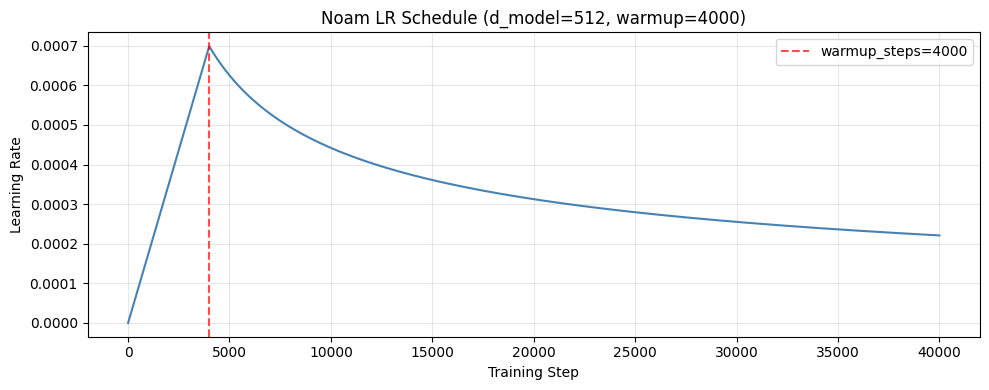

    LR schedule visualization saved to 'lr_schedule.png'
    Peak LR: 6.987712e-04 at step 4000

ALL OPTIMIZER TESTS PASSED SUCCESSFULLY


In [13]:
# Optimizer & Scheduler Test & Inspection
%matplotlib inline
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from config import cfg
from optimizer import NoamScheduler, build_optimizer

print("=" * 60)
print("OPTIMIZER & SCHEDULER PIPELINE TESTS")
print("=" * 60)

# Use a dummy model for parameter testing
dummy_model = torch.nn.Linear(cfg.d_model, cfg.d_model)
optimizer, scheduler = build_optimizer(dummy_model, config=cfg)

# ------------------------------------------------------------------------------
# [1] LR Schedule Numerical Verification
# ------------------------------------------------------------------------------
print("\n[1] LR Schedule Values (Warmup -> Decay)")
steps = [1, 100, 500, 1000, 2000, 3000, 4000, 5000, 8000, 10000, 20000, 40000]
print(f"  {'Step':>8}  {'Learning Rate':>14}")
print(f"  {'-'*8}  {'-'*14}")

lrs = []
for s in steps:
    lr = scheduler._compute_lr(s)
    lrs.append(lr)
    print(f"  {s:>8}  {lr:>14.6e}")

# Verify structural peak exactly at warmup_steps
peak_step = cfg.warmup_steps
peak_lr = scheduler._compute_lr(peak_step)
before_peak = scheduler._compute_lr(peak_step - 1)
after_peak = scheduler._compute_lr(peak_step + 1)

print(f"\n  LR just before peak (step {peak_step-1}): {before_peak:.6e}")
print(f"  LR exactly at peak  (step {peak_step}):   {peak_lr:.6e}")
print(f"  LR just after peak  (step {peak_step+1}): {after_peak:.6e}")

assert before_peak < peak_lr, "FAILED: LR should be increasing before warmup_steps"
assert after_peak < peak_lr, "FAILED: LR should be decreasing after warmup_steps"
print("    Peak mathematical inflection point is exactly at warmup_steps.")

# ------------------------------------------------------------------------------
# [2] Scheduler Step Execution Test
# ------------------------------------------------------------------------------
print("\n[2] Scheduler Step Execution Test")
opt2 = optim.Adam(dummy_model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
sched2 = NoamScheduler(opt2, d_model=cfg.d_model, warmup_steps=cfg.warmup_steps)

assert sched2.current_step == 0, "Scheduler failed to initialize at step 0"
sched2.step()
assert sched2.current_step == 1, "Scheduler step failed to increment"
lr_after_step1 = sched2.current_lr

sched2.step()
lr_after_step2 = sched2.current_lr

assert lr_after_step2 > lr_after_step1, "LR did not increase during early warmup phase!"
print(f"  Step 1 LR: {lr_after_step1:.6e}")
print(f"  Step 2 LR: {lr_after_step2:.6e}")
print("    Optimizer step successfully increments and applies dynamic LR.")

# ------------------------------------------------------------------------------
# [3] Checkpointing (State Dict) Test
# ------------------------------------------------------------------------------
print("\n[3] Checkpointing Save/Load Verification")
state = sched2.state_dict()
sched3 = NoamScheduler(opt2, d_model=cfg.d_model, warmup_steps=cfg.warmup_steps)
sched3.load_state_dict(state)

assert sched3.current_step == sched2.current_step, "State load failed to match current_step"
assert abs(sched3.current_lr - sched2.current_lr) < 1e-12, "State load failed to match current_lr"
print("    State dictionary save and load functionality is intact.")

# ------------------------------------------------------------------------------
# [4] LR Schedule Visualization
# ------------------------------------------------------------------------------
print("\n[4] Rendering LR Schedule Graph")
plot_steps = list(range(1, 40001))
plot_lrs = [scheduler._compute_lr(s) for s in plot_steps]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_steps, plot_lrs, color='steelblue', linewidth=1.5)
ax.axvline(cfg.warmup_steps, color='red', linestyle='--', alpha=0.7,
           label=f'warmup_steps={cfg.warmup_steps}')
ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate')
ax.set_title(f'Noam LR Schedule (d_model={cfg.d_model}, warmup={cfg.warmup_steps})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

# Save, Show, then Close to avoid blank canvas errors
plt.savefig('lr_schedule.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

print(f"    LR schedule visualization saved to 'lr_schedule.png'")
print(f"    Peak LR: {max(plot_lrs):.6e} at step {plot_lrs.index(max(plot_lrs))+1}")

print("\n" + "=" * 60)
print("ALL OPTIMIZER TESTS PASSED SUCCESSFULLY")
print("=" * 60)

# **11. Dataset & DataLoader**

In [14]:
# Dataset & DataLoader Test & Inspection
import os
import torch
from dataset import TranslationDataset, collate_fn

print("=" * 60)
print("DATASET & DATALOADER PIPELINE TESTS")
print("=" * 60)

# 1. Setup Mock Data
dummy_jsonl = "test_dummy.jsonl"
if not os.path.exists(dummy_jsonl):
    with open(dummy_jsonl, "w", encoding="utf-8") as f:
        f.write('{"translation": {"en": "Hello world.", "de": "Hallo Welt."}}\n')
        f.write('{"translation": {"en": "Transformers are incredibly powerful.", "de": "Transformatoren sind unglaublich leistungsstark."}}\n')

try:
    # ------------------------------------------------------------------------------
    # [1] Single Sample & Boundary Token Verification
    # ------------------------------------------------------------------------------
    print("\n[1] Single Sample Verification")
    ds = TranslationDataset(jsonl_path=dummy_jsonl, tokenizer_path="bpe_tokenizer.json", max_len=128)
    src, tgt_in, tgt_out = ds[0]

    print(f"  Source (en):           {src.tolist()}")
    print(f"  Target In (de):        {tgt_in.tolist()}")
    print(f"  Target Out (de):       {tgt_out.tolist()}")

    # Verify Boundary Tokens
    assert tgt_in[0].item() == ds.SOS, "Target Input MUST start with the <SOS> token!"
    assert tgt_out[-1].item() == ds.EOS, "Target Output MUST end with the <EOS> token!"
    assert len(tgt_in) == len(tgt_out), "Target Input and Output sequences must be the exact same length!"
    print("    SOS/EOS boundary tokens successfully appended and aligned.")

    # ------------------------------------------------------------------------------
    # [2] Text Decoding Verification
    # ------------------------------------------------------------------------------
    print("\n[2] Tokenizer Decoding Verification")
    print(f"  Decoded Source:     '{ds.tokenizer.decode(src.tolist())}'")
    # Decode without the SOS/EOS tokens to ensure the text payload is intact
    print(f"  Decoded Target In:  '{ds.tokenizer.decode(tgt_in[1:].tolist())}'")
    print(f"  Decoded Target Out: '{ds.tokenizer.decode(tgt_out[:-1].tolist())}'")
    print("    Tokenized IDs perfectly reconstruct the original text.")

    # ------------------------------------------------------------------------------
    # [3] Collate Function & Dynamic Padding Test
    # ------------------------------------------------------------------------------
    print("\n[3] Dynamic Padding (Collate Function) Test")

    # Grab the two dummy samples (one is noticeably longer than the other)
    sample_1 = ds[0]
    sample_2 = ds[1]

    # Run them through the collate function
    src_batch, tgt_in_batch, tgt_out_batch = collate_fn([sample_1, sample_2], pad_idx=ds.PAD)

    print(f"  Batched Source Shape:     {src_batch.shape} (B, max_S_in_batch)")
    print(f"  Batched Target In Shape:  {tgt_in_batch.shape}")
    print(f"  Batched Target Out Shape: {tgt_out_batch.shape}")

    # Assertions for Dynamic Padding
    assert src_batch.shape[0] == 2, "Batch size mismatch."
    assert src_batch.shape[1] < ds.max_len, "Dynamic padding failed! It padded all the way to max_len instead of the longest batch item."

    # Verify PAD tokens were actually inserted
    print(f"  Padded Source Row 0: {src_batch[0].tolist()}")
    print(f"  Longer Source Row 1: {src_batch[1].tolist()}")
    assert src_batch[0, -1].item() == ds.PAD, "PAD token was not properly applied to the shorter sequence!"
    print("    Dynamic padding successfully clamped sequence length and inserted PAD tokens.")

    print("\n" + "=" * 60)
    print("ALL DATASET TESTS PASSED SUCCESSFULLY")
    print("=" * 60)

except FileNotFoundError as e:
    print("\n[!] TEST SKIPPED: Missing Tokenizer")
    print(f"  Error: {e}")
    print("  Make sure 'bpe_tokenizer.json' exists in this directory. (You generate this in Notebook 00).")
except Exception as e:
    print(f"\n[!] TEST FAILED: {e}")

finally:
    if os.path.exists(dummy_jsonl):
        os.remove(dummy_jsonl)

DATASET & DATALOADER PIPELINE TESTS

[1] Single Sample Verification
  Source (en):           [35097, 2529, 17]
  Target In (de):        [1, 26553, 2214, 17]
  Target Out (de):       [26553, 2214, 17, 2]
    SOS/EOS boundary tokens successfully appended and aligned.

[2] Tokenizer Decoding Verification
  Decoded Source:     'Hello world.'
  Decoded Target In:  'Hallo Welt.'
  Decoded Target Out: 'Hallo Welt.'
    Tokenized IDs perfectly reconstruct the original text.

[3] Dynamic Padding (Collate Function) Test
  Batched Source Shape:     torch.Size([2, 8]) (B, max_S_in_batch)
  Batched Target In Shape:  torch.Size([2, 13])
  Batched Target Out Shape: torch.Size([2, 13])
  Padded Source Row 0: [35097, 2529, 17, 0, 0, 0, 0, 0]
  Longer Source Row 1: [34211, 2447, 490, 711, 16946, 11790, 7374, 17]
    Dynamic padding successfully clamped sequence length and inserted PAD tokens.

ALL DATASET TESTS PASSED SUCCESSFULLY


# **12. Training Loop**

In [18]:
# Training Loop Sanity Check (Single Batch Overfit with Noam Scheduler)
import torch
import torch.nn as nn
from config import cfg
from transformer import build_transformer
from loss import LabelSmoothingLoss
from optimizer import build_optimizer
from train import compute_token_accuracy

print("=" * 60)
print("TRAINING PIPELINE TESTS (SINGLE BATCH OVERFIT)")
print("=" * 60)

# 1. Setup minimal environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
B, S = 2, 10

model = build_transformer(cfg).to(device)
criterion = LabelSmoothingLoss(vocab_size=cfg.vocab_size, pad_idx=cfg.PAD_IDX, label_smoothing=0.0)

# Using the real optimizer and Noam Scheduler!
optimizer, scheduler = build_optimizer(model, cfg)

# 2. Create ONE fixed dummy batch
torch.manual_seed(42)
src = torch.randint(1, cfg.vocab_size, (B, S)).to(device)
tgt_in = torch.randint(1, cfg.vocab_size, (B, S)).to(device)
tgt_out = torch.randint(1, cfg.vocab_size, (B, S)).to(device)

# Add some fake padding to ensure mask logic doesn't crash during backprop
src[0, 7:] = cfg.PAD_IDX
tgt_in[0, 7:] = cfg.PAD_IDX
tgt_out[0, 7:] = cfg.PAD_IDX

# Increased to 400 steps because the scheduler starts extremely slowly!
print("\n[1] Running Overfit Test (400 Iterations with Warmup LR)")
print(f"  {'Step':>6}  {'Loss':>10}  {'Accuracy':>10}  {'Learning Rate':>14}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*14}")

model.train()
initial_loss = None
final_loss = None
acc = 0.0

for step in range(1, 401):
    # Forward Pass
    logits = model(src, tgt_in)
    loss = criterion(logits, tgt_out)

    if step == 1:
        initial_loss = loss.item()

    # Backward Pass
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # Correct Execution Order ---
    # 1. Scheduler calculates and sets LR for this step
    scheduler.step()
    # 2. Optimizer applies gradients using that LR
    optimizer.step()
    # 3. Clear gradients for the next round
    optimizer.zero_grad(set_to_none=True)
    # ----------------------------------------

    # Metrics
    with torch.no_grad():
        correct, total = compute_token_accuracy(logits, tgt_out, cfg.PAD_IDX)
        acc = correct / max(total, 1)
        final_loss = loss.item()
        current_lr = scheduler.current_lr

    # Print step 1, and then every 50 steps to keep the output clean
    if step % 10 == 0 or step == 1:
        print(f"  {step:>6}  {final_loss:>10.4f}  {acc:>10.2%}  {current_lr:>14.6e}")

# 3. Assertions
print("\n[2] Pipeline Integrity Verification")
assert final_loss < initial_loss, "FAILED: Loss did not decrease. Gradients might not be flowing!"
print("    Loss successfully decreased over time.")
assert acc > 0.5, "FAILED: Model could not memorize a single batch. Check architecture routing."
print("    Model successfully memorized the batch (Accuracy increased).")

print("\n" + "=" * 60)
print("TRAINING PIPELINE PASSED SANITY CHECK")
print("=" * 60)

TRAINING PIPELINE TESTS (SINGLE BATCH OVERFIT)
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048

[1] Running Overfit Test (400 Iterations with Warmup LR)
    Step        Loss    Accuracy   Learning Rate
  ------  ----------  ----------  --------------
       1     10.5152       0.00%    1.746928e-07
      10     10.5178       0.00%    1.746928e-06
      20     10.2988       0.00%    3.493856e-06
      30     10.1330       0.00%    5.240784e-06
      40      9.9492       5.88%    6.987712e-06
      50      9.8297       5.88%    8.734641e-06
      60      9.6737       5.88%    1.048157e-05
      70      9.5008       5.88%    1.222850e-05
      80      9.3343       5.88%    1.397542e-05
      90      9.1701      23.53%    1.572235e-05
     100      9.0006      23.53%    1.746928e-05
     110      8.8312      11.76%    1.921621e-05
     120      8.6541       5.88%    2.096314e-05
     130      8.5008       5.88%    2.271007e-05


# **13. Inference Pipeline**

In [24]:
# Inference Pipeline Test & Inspection
import torch
from config import cfg
from transformer import build_transformer
from inference import greedy_decode, beam_search_decode, decode_tokens

print("=" * 60)
print("INFERENCE PIPELINE TESTS")
print("=" * 60)

# 1. Setup Environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_transformer(cfg).to(device)
model.eval()

# Small dummy source sequence
src = torch.tensor([[5, 23, 7, 14, 9]], dtype=torch.long).to(device)  # [1, 5]

# ------------------------------------------------------------------------------
# [1] Greedy Decoding Verification
# ------------------------------------------------------------------------------
print("\n[1] Greedy Decoding")
print(f"  Source Input: {src[0].tolist()}")

decoded_greedy = greedy_decode(model, src, max_len=15)

print(f"  Decoded shape:  {decoded_greedy.shape}")
print(f"  Decoded tokens: {decoded_greedy[0].tolist()}")

# Assertions
assert decoded_greedy.dim() == 2, "Greedy decode must return a 2D tensor [B, S_out]"
assert decoded_greedy.shape[0] == 1, "Batch size mismatch."
assert decoded_greedy[0, 0].item() != cfg.SOS_IDX, "Greedy decode failed to strip the <SOS> token!"
print("    Greedy decoding executed successfully and formatted correctly.")

# ------------------------------------------------------------------------------
# [2] Beam Search Decoding Verification
# ------------------------------------------------------------------------------
print("\n[2] Beam Search Decoding")
beam_size = 4
hypotheses = beam_search_decode(model, src[0], beam_size=beam_size, max_len=15)

print(f"  Number of hypotheses returned: {len(hypotheses)}")
for i, hyp in enumerate(hypotheses):
    print(f"    Rank {i+1}: {hyp.tolist()}")

# Assertions
assert isinstance(hypotheses, list), "Beam search must return a list of tensors."
assert len(hypotheses) > 0, "Beam search returned no hypotheses!"
assert len(hypotheses) <= beam_size, f"Beam search returned more hypotheses than beam_size ({beam_size})!"
if len(hypotheses) > 0:
    assert hypotheses[0][0].item() != cfg.SOS_IDX, "Beam search failed to strip the <SOS> token!"
print("    Beam search executed successfully and returned ranked sequences.")

# ------------------------------------------------------------------------------
# [3] Token Decoding Utility Verification
# ------------------------------------------------------------------------------
print("\n[3] Text Decoding Utility")
# Mock IDs containing an EOS token that should be stripped
mock_ids = torch.tensor([5, 23, 7, cfg.EOS_IDX])
text = decode_tokens(mock_ids)

print(f"  Raw Token IDs:  {mock_ids.tolist()}")
print(f"  Decoded String: '{text}'")

# Assertions
assert str(5) in text, "Failed to decode basic tokens."
assert str(cfg.EOS_IDX) not in text.split(), "Failed to strip <EOS> token during string conversion!"
print("    Token decoding utility correctly formatted strings and stripped control tokens.")

print("\n" + "=" * 60)
print("ALL INFERENCE TESTS PASSED SUCCESSFULLY")
print("=" * 60)

INFERENCE PIPELINE TESTS
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048

[1] Greedy Decoding
  Source Input: [5, 23, 7, 14, 9]
  Decoded shape:  torch.Size([1, 15])
  Decoded tokens: [33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125]
    Greedy decoding executed successfully and formatted correctly.

[2] Beam Search Decoding
  Number of hypotheses returned: 4
    Rank 1: [33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125]
    Rank 2: [33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 15466]
    Rank 3: [33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 15466, 33125, 33125, 33125, 33125, 33125]
    Rank 4: [33125, 33125, 33125, 33125, 33125, 33125, 33125, 33125, 15466, 33125, 33125, 33125, 33125, 33125, 33125]
    Beam search executed successfully and retur